In [1]:
from simfile import SimFile
from simulation import Simulation
from validation import switchOffAllEffects
import os
import numpy as np
import matplotlib.pyplot as plt
import scipy.constants as constants

In [2]:
starCatalogFilename = os.environ["PLATO_PROJECT_HOME"] + "/docs/validation/PIC1.0.0target.csv"

In [3]:
sim = Simulation("FieldDistortion")
switchOffAllEffects(sim)
sim.outputDir = os.environ["PLATO_WORKDIR"]

# One full-frame exposure

sim["ObservingParameters/NumExposures"] = 1
sim["SubField/NumRows"] = 4510
sim["SubField/NumColumns"] = 4510

sim["ObservingParameters/StarCatalogFile"] = os.environ["PLATO_PROJECT_HOME"] + "/docs/validation/PIC1.0.0target.csv"
sim["ObservingParameters/RApointing"] = 115
sim["ObservingParameters/DecPointing"] = -46

sim["Camera/IncludeFieldDistortion"] = "no"
output = sim.run(removeOutputFile = True)

In [4]:
resultUndistorted = output.getStarCoordinates(0)
idUndistorted = resultUndistorted[0]
xUndistorted = resultUndistorted[3]
yUndistorted = resultUndistorted[4]

In [5]:
sim["Camera/IncludeFieldDistortion"] = "yes"
output = sim.run(removeOutputFile = True)

resultDistorted = output.getStarCoordinates(0)
idDistorted = resultDistorted[0]
xDistorted = resultDistorted[3]
yDistorted = resultDistorted[4]

In [6]:
commonId = np.intersect1d(idDistorted, idUndistorted)

selectionDistorted = np.isin(idDistorted, commonId)
selectionUndistorted = np.isin(idUndistorted, commonId)

In [7]:
xDistorted = xDistorted[selectionDistorted]
yDistorted = yDistorted[selectionDistorted]
rDistorted = np.sqrt(xDistorted**2 + yDistorted**2)

xUndistorted = xUndistorted[selectionUndistorted]
yUndistorted = yUndistorted[selectionUndistorted]
rUndistorted = np.sqrt(xUndistorted**2 + yUndistorted**2)

In [8]:
fovDegrees = sim["CCD/Vignetting/MechanicalVignetting/RadiusFOV"]
plateScaleArcsec = 15
fovPixels = fovDegrees / plateScaleArcsec * constants.degree / constants.arcsec
fovMm = fovPixels / 1000 * 18
focalLength = sim["Camera/FocalLength/ConstantValue"] * 1000

# Position angle

In [9]:
angleDistorted = np.rad2deg(np.arctan2(yDistorted, xDistorted))
angleUndistorted = np.rad2deg(np.arctan2(yUndistorted, xUndistorted))

(0, 18.8908)

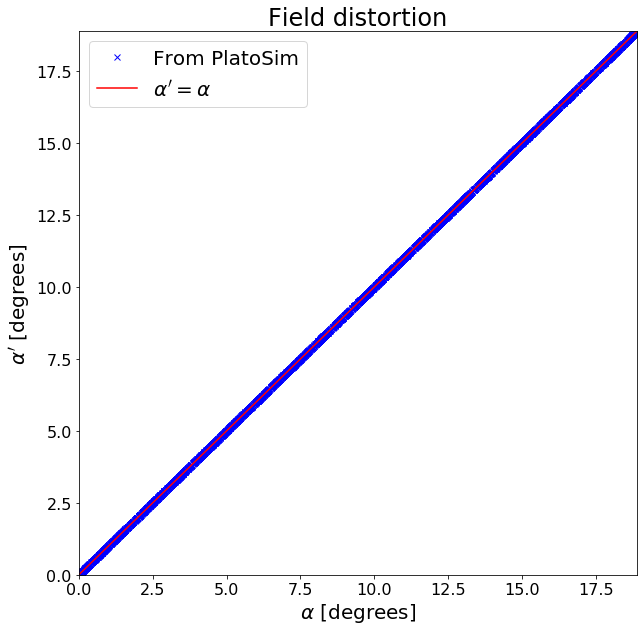

In [10]:
fig = plt.figure(figsize = (10, 10))
ax = fig.add_subplot(1, 1, 1)



###############
# From PlatoSim
###############

plt.plot(angleDistorted, angleUndistorted, "bx", label = "From PlatoSim")



########
# 𝞀' = 𝞀
########

plt.plot([0,180], [0,180], "r", label = "$\\alpha' = \\alpha$")




########
# Layout
########

plt.title("Field distortion", fontsize = 24)
plt.legend(loc='best', fontsize = 20)

for tick in ax.xaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
for tick in ax.yaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
plt.xlabel("$\\alpha$ [degrees]", fontsize = 20)
plt.ylabel("$\\alpha'$ [degrees]", fontsize = 20)

plt.xlim([0, fovDegrees])
plt.ylim([0, fovDegrees])

# $\Delta r_{FP} = r'_{FP} - r_{FP}$

(-0.2, 3.5)

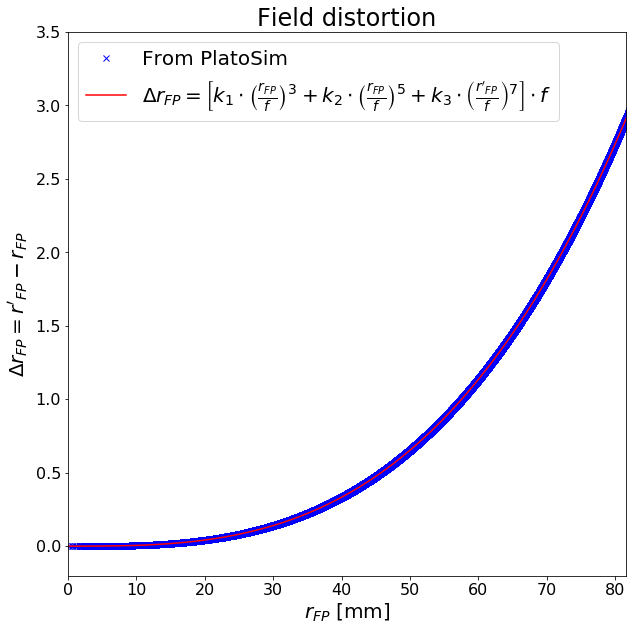

In [11]:
fig = plt.figure(figsize = (10, 10))
ax = fig.add_subplot(1, 1, 1)



###############
# From PlatoSim
###############

plt.plot(rUndistorted, rDistorted - rUndistorted, "bx", label = "From PlatoSim")




####################################################
# ∆r_FP  = [k_1∙ r_FP^3+ k_2∙ r_FP^5  + k_3∙ r_FP^7]
####################################################

k1, k2, k3 = sim["Camera/FieldDistortion/ConstantCoefficients"]

r = np.arange(0, 85) / focalLength
rel = (k1 * r**3 + k2 * r**5 + k3 * r**7) * focalLength

plt.plot(r * focalLength, rel, "r", label = "$\Delta r_{FP} = \\left[k_1 \cdot \\left( \\frac{r_{FP}}{f} \\right)^3 + k_2 \cdot \\left( \\frac{r_{FP}}{f} \\right)^5 + k_3 \cdot \\left( \\frac{r'_{FP}}{f} \\right)^7 \\right] \cdot f$")


########
# Layout
########

plt.xlabel("$r_{FP}$ [mm]", fontsize = 20)
plt.ylabel("$\Delta r_{FP} = r'_{FP} - r_{FP}$", fontsize = 20)

plt.title("Field distortion", fontsize = 24)
plt.legend(loc='best', fontsize = 20)

for tick in ax.xaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
for tick in ax.yaxis.get_major_ticks():
    tick.label.set_fontsize(16)

plt.xlim([0, fovMm])
plt.ylim([-0.2, 3.5])

# $\Delta r'_{FP} = r_{FP} - r'_{FP}$

(-3.5, 0.2)

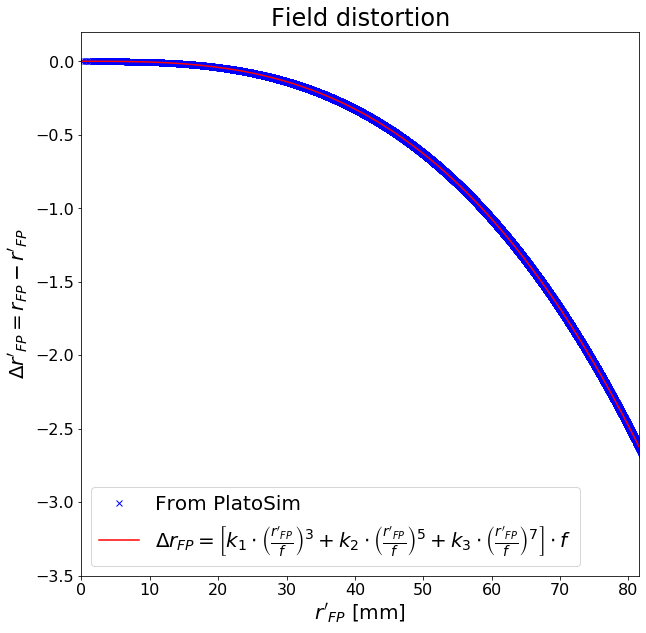

In [12]:
fig = plt.figure(figsize = (10, 10))
ax = fig.add_subplot(1, 1, 1)



###############
# From PlatoSim
###############

plt.plot(rDistorted, rUndistorted - rDistorted, "bx", label = "From PlatoSim")




########################################################
# ∆r'_FP  = [k_1∙ r'_FP^3+ k_2∙ r'_FP^5  + k_3∙ r'_FP^7]
########################################################

k1, k2, k3 = sim["Camera/FieldDistortion/ConstantInverseCoefficients"]

r = np.arange(0, 85) / focalLength
rel = (k1 * r**3 + k2 * r**5 + k3 * r**7) * focalLength

plt.plot(r * focalLength, rel, "r", label = "$\Delta r_{FP} = \\left[k_1 \cdot \\left( \\frac{r'_{FP}}{f} \\right)^3 + k_2 \cdot \\left( \\frac{r'_{FP}}{f} \\right)^5 + k_3 \cdot \\left( \\frac{r'_{FP}}{f} \\right)^7 \\right] \cdot f$")



########
# Layout
########

plt.xlabel("$r'_{FP}$ [mm]", fontsize = 20)
plt.ylabel("$\Delta r'_{FP} = r_{FP} - r'_{FP}$", fontsize = 20)

plt.title("Field distortion", fontsize = 24)
plt.legend(loc='best', fontsize = 20)

for tick in ax.xaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
for tick in ax.yaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
plt.xlim([0, fovMm])
plt.ylim([-3.5, 0.2])